# Part III - NLP: Spam vs Ham SMS Classification

## Setup - Mount Drive and Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
zip_path = "/content/drive/MyDrive/Datasets/9.Spam vs Ham Sms Dataset.zip"
extract_path = "/content/spam_data"

!unzip -q "{zip_path}" -d "{extract_path}"

print(f"Successfully extracted to '{extract_path}'.")

Successfully extracted to '/content/spam_data'.


## Importing Libraries

In [5]:
!pip install -q wordcloud gensim contractions gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.5 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import contractions

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import Constant

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import gensim.downloader as api

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

print('all imports done')
print('tensorflow:', tf.__version__)

all imports done
tensorflow: 2.20.0


## Loading the Dataset

In [7]:
df = pd.read_csv('/content/spam_data/9.Spam vs Ham Sms Dataset/spamvsham.csv',
                 encoding='latin-1')

# only need first two columns, rest are empty
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print('shape:', df.shape)
print(df.head())

shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [8]:
print('null values:')
print(df.isnull().sum())
print()
print('class counts:')
print(df['label'].value_counts())

null values:
label      0
message    0
dtype: int64

class counts:
label
ham     4825
spam     747
Name: count, dtype: int64


## Data Visualization

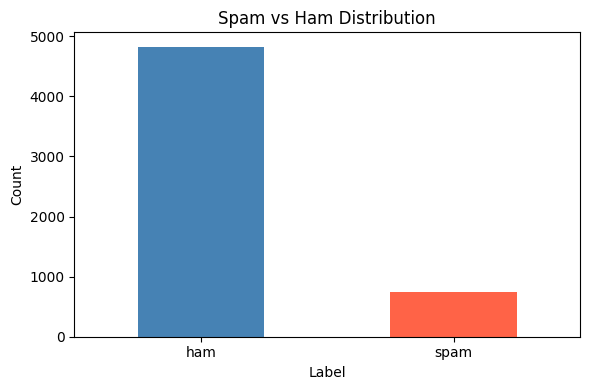

ham: 4825
spam: 747


In [9]:
# class distribution - dataset is imbalanced (more ham than spam)
plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('ham:', df['label'].value_counts()['ham'])
print('spam:', df['label'].value_counts()['spam'])

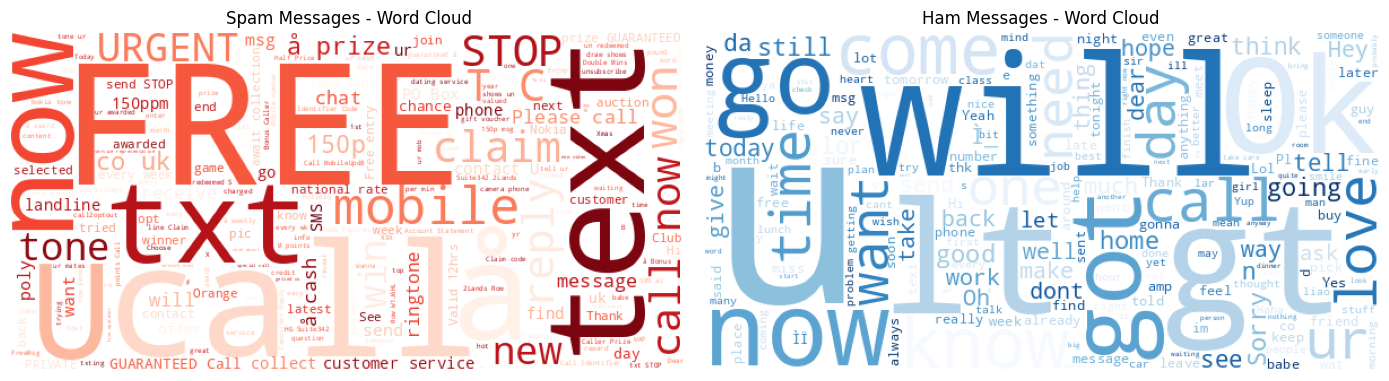

In [10]:
# wordcloud for spam and ham
spam_words = ' '.join(df[df['label']=='spam']['message'])
ham_words = ' '.join(df[df['label']=='ham']['message'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_spam = WordCloud(width=600, height=300, background_color='white', colormap='Reds').generate(spam_words)
axes[0].imshow(wc_spam)
axes[0].set_title('Spam Messages - Word Cloud')
axes[0].axis('off')

wc_ham = WordCloud(width=600, height=300, background_color='white', colormap='Blues').generate(ham_words)
axes[1].imshow(wc_ham)
axes[1].set_title('Ham Messages - Word Cloud')
axes[1].axis('off')

plt.tight_layout()
plt.show()

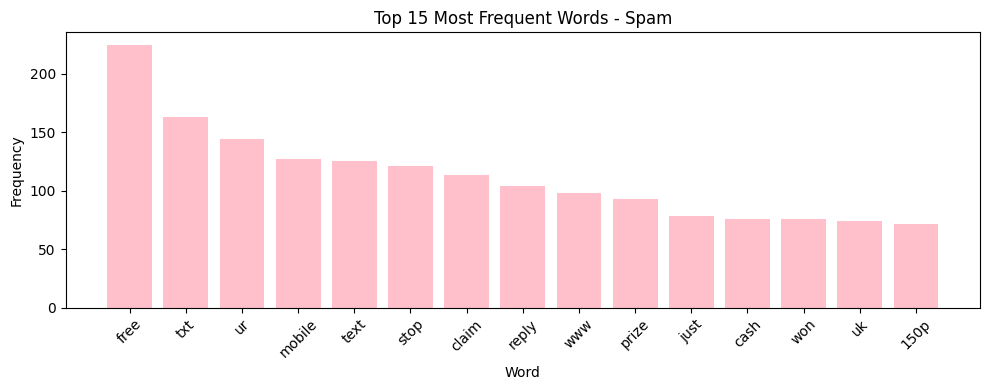

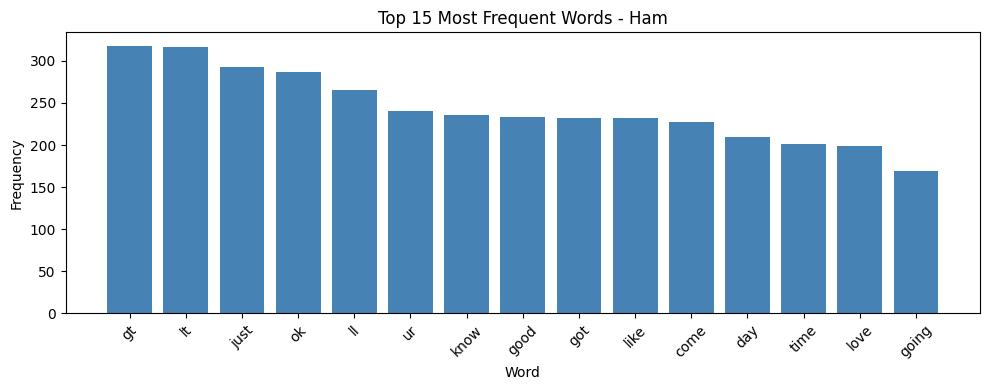

In [14]:
# top 15 most frequent words in spam vs ham
def plot_top_words(text_series, label, color, n=15):
    vec = CountVectorizer(max_features=n, stop_words='english')
    vec.fit(text_series)
    word_counts = vec.transform(text_series).toarray().sum(axis=0)
    words = vec.get_feature_names_out()

    sorted_idx = word_counts.argsort()[::-1]
    top_words  = [words[i] for i in sorted_idx]
    top_counts = [word_counts[i] for i in sorted_idx]

    plt.figure(figsize=(10, 4))
    plt.bar(top_words, top_counts, color=color)
    plt.title(f'Top {n} Most Frequent Words - {label}')
    plt.xlabel('Word')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_top_words(df[df['label']=='spam']['message'], 'Spam', 'pink')
plot_top_words(df[df['label']=='ham']['message'], 'Ham', 'steelblue')

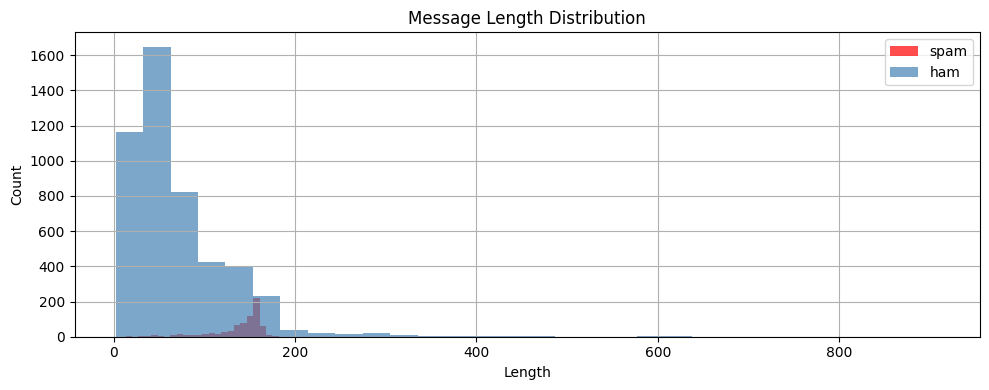

avg spam length: 138.9
avg ham length: 71.0


In [18]:
# message length distribution
df['msg_length'] = df['message'].apply(len)

plt.figure(figsize=(10, 4))
df[df['label']=='spam']['msg_length'].hist(bins=30, alpha=0.7, label='spam', color='red')
df[df['label']=='ham']['msg_length'].hist(bins=30, alpha=0.7, label='ham', color='steelblue')
plt.title('Message Length Distribution')
plt.xlabel('Length')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

# spam messages tend to be longer
print('avg spam length:', df[df['label']=='spam']['msg_length'].mean().round(1))
print('avg ham length:', df[df['label']=='ham']['msg_length'].mean().round(1))

## Text Preprocessing

In [19]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # lowercase
    text = text.lower()
    # expand contractions (don't → do not, can't → cannot)
    text = contractions.fix(text)
    # remove numbers
    text = re.sub(r'\d+', '', text)
    # remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # remove stopwords and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

df['cleaned'] = df['message'].apply(clean_text)

# checking before and after
print('original:', df['message'][2])
print('cleaned :', df['cleaned'][2])

original: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
cleaned : free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply over


In [20]:
# drop any empty rows after cleaning
df = df[df['cleaned'].str.strip() != '']
df = df.dropna(subset=['cleaned'])
print('dataset size after cleaning:', len(df))

dataset size after cleaning: 5562


## Tokenization and Padding

In [21]:
# convert labels to binary
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['cleaned']
y = df['label_num']

# 80/20 split with stratify to keep class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('train size:', len(X_train))
print('test size:', len(X_test))
print('train spam ratio:', y_train.mean().round(3))

train size: 4449
test size: 1113
train spam ratio: 0.134


In [22]:
# showing the full split breakdown clearly
val_size = int(len(X_train) * 0.2)
print('dataset split breakdown:')
print(f'  total dataset : {len(df)}')
print(f'  train         : {len(X_train)} (80% of total)')
print(f'  validation    : {val_size} (20% of train, used during model training)')
print(f'  test          : {len(X_test)} (20% of total, held out - never seen during training)')
print()
print('label distribution in train set:')
print(y_train.value_counts().rename({0:'ham', 1:'spam'}))
print()
print('label distribution in test set:')
print(y_test.value_counts().rename({0:'ham', 1:'spam'}))

dataset split breakdown:
  total dataset : 5562
  train         : 4449 (80% of total)
  validation    : 889 (20% of train, used during model training)
  test          : 1113 (20% of total, held out - never seen during training)

label distribution in train set:
label_num
ham     3851
spam     598
Name: count, dtype: int64

label distribution in test set:
label_num
ham     964
spam    149
Name: count, dtype: int64


In [23]:
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

vocab_size = len(tokenizer.word_index) + 1
print('vocab size:', vocab_size)

# checking sequence lengths to decide padding length
lengths = [len(s) for s in X_train_seq]
print('avg sequence length:', round(sum(lengths)/len(lengths), 1))
print('max sequence length:', max(lengths))
print('95th percentile:', int(np.percentile(lengths, 95)))

vocab size: 6950
avg sequence length: 8.3
max sequence length: 70
95th percentile: 19


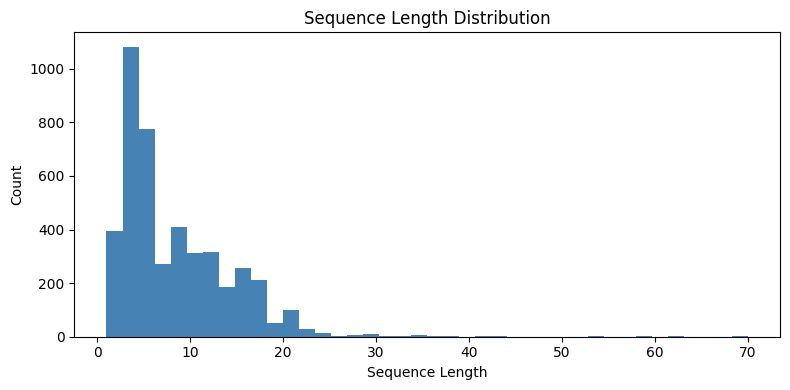

In [24]:
# sequence length distribution
plt.figure(figsize=(8,4))
plt.hist(lengths, bins=40, color='steelblue')
plt.title('Sequence Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [25]:
# using 95th percentile as max length to avoid too much padding
MAX_LEN = int(np.percentile(lengths, 95))
print('using max_len:', MAX_LEN)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post')

print('train shape:', X_train_pad.shape)
print('test shape:', X_test_pad.shape)

using max_len: 19
train shape: (4449, 19)
test shape: (1113, 19)


---
## Model 1: Simple RNN

In [26]:
EMBED_DIM = 64

model_rnn = Sequential(name='simple_rnn')
model_rnn.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
model_rnn.add(SimpleRNN(32, return_sequences=False))
model_rnn.add(Dropout(0.3))
model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_rnn.summary()

Model: "simple_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print('training simple rnn...')
history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[es]
)

training simple rnn...
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8932 - loss: 0.3034 - val_accuracy: 0.9640 - val_loss: 0.1186
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9834 - loss: 0.0809 - val_accuracy: 0.9663 - val_loss: 0.0895
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9913 - loss: 0.0398 - val_accuracy: 0.9607 - val_loss: 0.1100
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9919 - loss: 0.0368 - val_accuracy: 0.9719 - val_loss: 0.0839
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9947 - loss: 0.0257 - val_accuracy: 0.9596 - val_loss: 0.1279
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9992 - loss: 0.0119 - val_accuracy: 0.9652 - val_loss: 0.1204
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9989 - loss: 0.0099 - val_accuracy: 0.9483 - val_loss: 0.1930
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


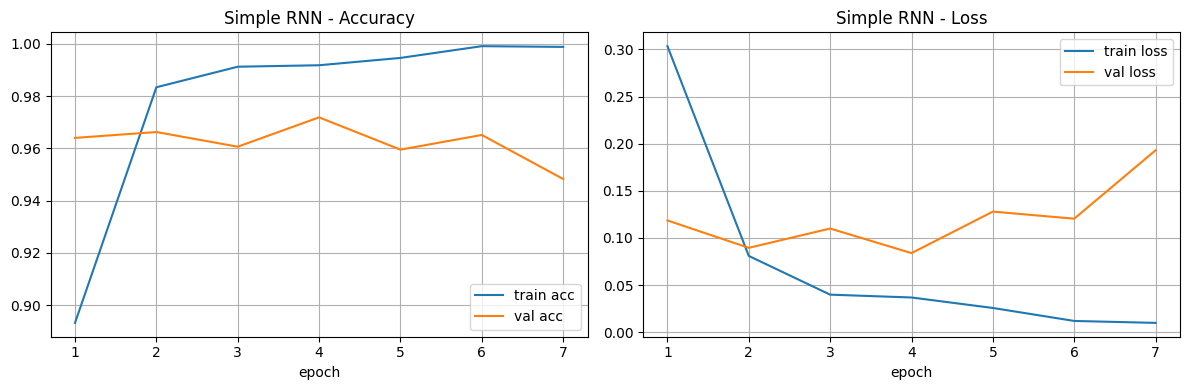

In [28]:
def plot_curves(hist, title):
    acc     = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss    = hist.history['loss']
    val_loss= hist.history['val_loss']
    ep = range(1, len(acc)+1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1,2,1)
    plt.plot(ep, acc, label='train acc')
    plt.plot(ep, val_acc, label='val acc')
    plt.title(title + ' - Accuracy')
    plt.xlabel('epoch'); plt.legend(); plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(ep, loss, label='train loss')
    plt.plot(ep, val_loss, label='val loss')
    plt.title(title + ' - Loss')
    plt.xlabel('epoch'); plt.legend(); plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_curves(history_rnn, 'Simple RNN')

In [29]:
loss_rnn, acc_rnn = model_rnn.evaluate(X_test_pad, y_test, verbose=0)
print(f'RNN test accuracy: {acc_rnn*100:.2f}%')
print(f'RNN test loss: {loss_rnn:.4f}')

y_pred_rnn = (model_rnn.predict(X_test_pad, verbose=0) > 0.5).astype(int)

print('\nClassification Report - RNN:')
print(classification_report(y_test, y_pred_rnn, target_names=['ham', 'spam']))

RNN test accuracy: 97.57%
RNN test loss: 0.0992

Classification Report - RNN:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       964
        spam       0.97      0.85      0.90       149

    accuracy                           0.98      1113
   macro avg       0.97      0.92      0.94      1113
weighted avg       0.98      0.98      0.98      1113



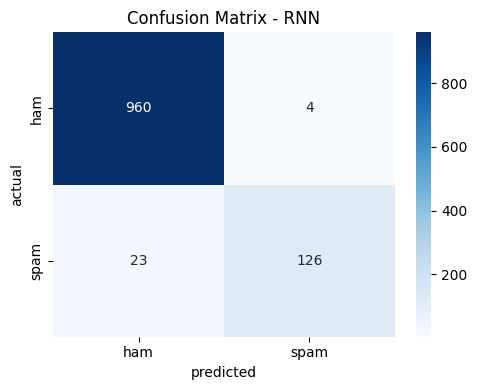

In [30]:
cm_rnn = confusion_matrix(y_test, y_pred_rnn)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('Confusion Matrix - RNN')
plt.xlabel('predicted'); plt.ylabel('actual')
plt.tight_layout()
plt.show()

## Model 2: LSTM

In [31]:
model_lstm = Sequential(name='lstm_model')
model_lstm.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
model_lstm.add(LSTM(64, return_sequences=False))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_lstm.summary()

Model: "lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

training lstm...
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8915 - loss: 0.3067 - val_accuracy: 0.9539 - val_loss: 0.1183
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9806 - loss: 0.0759 - val_accuracy: 0.9798 - val_loss: 0.0660
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9938 - loss: 0.0288 - val_accuracy: 0.9809 - val_loss: 0.0642
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9966 - loss: 0.0135 - val_accuracy: 0.9719 - val_loss: 0.1012
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9992 - loss: 0.0042 - val_accuracy: 0.9753 - val_loss: 0.0844
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9742 - val_loss: 0.1083
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


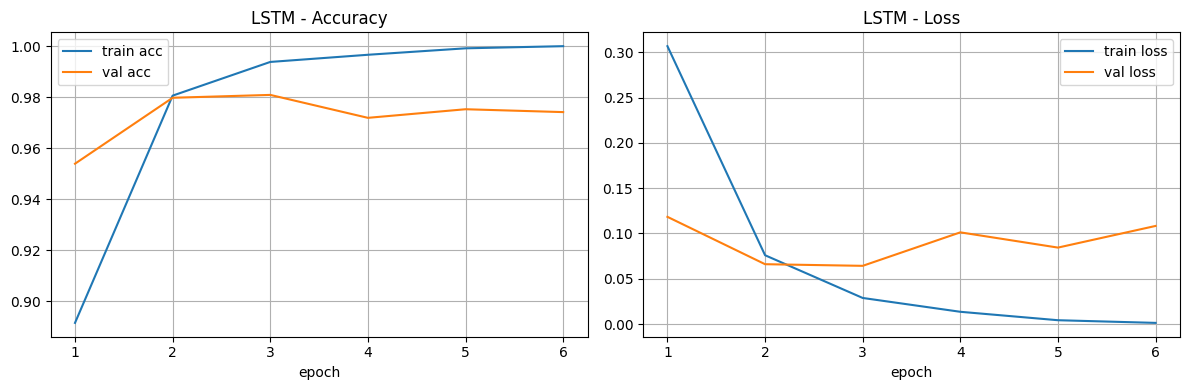

In [32]:
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print('training lstm...')
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[es]
)

plot_curves(history_lstm, 'LSTM')

In [33]:
loss_lstm, acc_lstm = model_lstm.evaluate(X_test_pad, y_test, verbose=0)
print(f'LSTM test accuracy: {acc_lstm*100:.2f}%')
print(f'LSTM test loss: {loss_lstm:.4f}')

y_pred_lstm = (model_lstm.predict(X_test_pad, verbose=0) > 0.5).astype(int)

print('\nClassification Report - LSTM:')
print(classification_report(y_test, y_pred_lstm, target_names=['ham', 'spam']))

LSTM test accuracy: 98.29%
LSTM test loss: 0.0632

Classification Report - LSTM:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       964
        spam       0.96      0.91      0.93       149

    accuracy                           0.98      1113
   macro avg       0.97      0.95      0.96      1113
weighted avg       0.98      0.98      0.98      1113



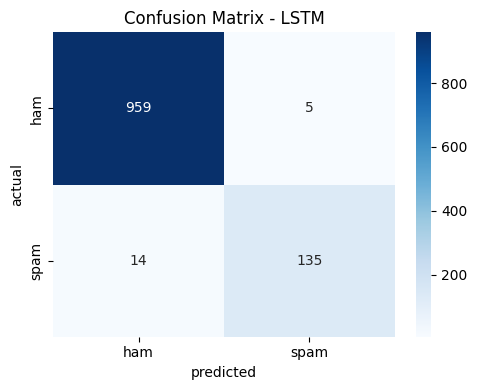

In [34]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('Confusion Matrix - LSTM')
plt.xlabel('predicted'); plt.ylabel('actual')
plt.tight_layout()
plt.show()

## Model 3: LSTM with Word2Vec Embeddings

In [35]:
# loading pretrained word2vec - this will take a few minutes to download
print('loading word2vec...')
w2v = api.load('word2vec-google-news-300')
print('word2vec loaded!')

loading word2vec...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
word2vec loaded!


In [36]:
# building embedding matrix from word2vec
EMBED_DIM_W2V = 300

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))

found = 0
for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        if word in w2v:
            embedding_matrix[i] = w2v[word]
            found += 1

print(f'words found in word2vec: {found} out of {min(VOCAB_SIZE, len(tokenizer.word_index))}')

words found in word2vec: 4871 out of 6949


In [37]:
model_w2v = Sequential(name='lstm_w2v')
model_w2v.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM_W2V,
    input_length=MAX_LEN,
    embeddings_initializer=Constant(embedding_matrix),
    trainable=False  # freezing pretrained weights
))
model_w2v.add(LSTM(64, return_sequences=False))
model_w2v.add(Dropout(0.5))
model_w2v.add(Dense(1, activation='sigmoid'))

model_w2v.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_w2v.summary()

Model: "lstm_w2v"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

training lstm + word2vec...
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9121 - loss: 0.3039 - val_accuracy: 0.9629 - val_loss: 0.1244
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9638 - loss: 0.1147 - val_accuracy: 0.9685 - val_loss: 0.0995
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9770 - loss: 0.0826 - val_accuracy: 0.9787 - val_loss: 0.0770
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9786 - loss: 0.0674 - val_accuracy: 0.9787 - val_loss: 0.0717
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9854 - loss: 0.0529 - val_accuracy: 0.9820 - val_loss: 0.0646
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9885 - loss: 0.0444 - val_accuracy: 0.9753 - val_loss: 0.0775
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9879 - loss: 0.0425 - val_accuracy: 0.9685 - val_loss: 0.0785
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9907 - loss: 0.0416 - va

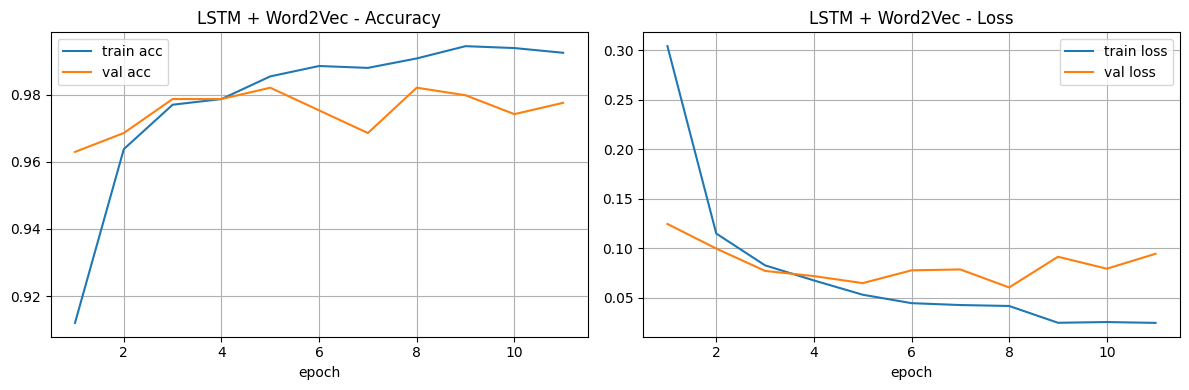

In [38]:
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print('training lstm + word2vec...')
history_w2v = model_w2v.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[es]
)

plot_curves(history_w2v, 'LSTM + Word2Vec')

In [39]:
loss_w2v, acc_w2v = model_w2v.evaluate(X_test_pad, y_test, verbose=0)
print(f'LSTM+W2V test accuracy: {acc_w2v*100:.2f}%')
print(f'LSTM+W2V test loss: {loss_w2v:.4f}')

y_pred_w2v = (model_w2v.predict(X_test_pad, verbose=0) > 0.5).astype(int)

print('\nClassification Report - LSTM + Word2Vec:')
print(classification_report(y_test, y_pred_w2v, target_names=['ham', 'spam']))

LSTM+W2V test accuracy: 97.84%
LSTM+W2V test loss: 0.0718

Classification Report - LSTM + Word2Vec:
              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       964
        spam       0.94      0.90      0.92       149

    accuracy                           0.98      1113
   macro avg       0.96      0.94      0.95      1113
weighted avg       0.98      0.98      0.98      1113



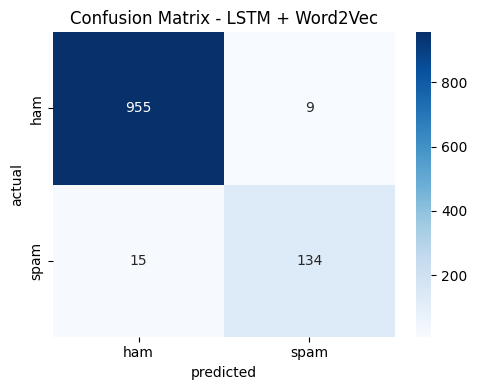

In [40]:
cm_w2v = confusion_matrix(y_test, y_pred_w2v)
plt.figure(figsize=(5,4))
sns.heatmap(cm_w2v, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham','spam'], yticklabels=['ham','spam'])
plt.title('Confusion Matrix - LSTM + Word2Vec')
plt.xlabel('predicted'); plt.ylabel('actual')
plt.tight_layout()
plt.show()

## Model Comparison

In [41]:
results = pd.DataFrame({
    'Model'    : ['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
    'Accuracy' : [f'{acc_rnn*100:.2f}%', f'{acc_lstm*100:.2f}%', f'{acc_w2v*100:.2f}%'],
    'Loss'     : [f'{loss_rnn:.4f}', f'{loss_lstm:.4f}', f'{loss_w2v:.4f}']
})

print(results.to_string(index=False))

          Model Accuracy   Loss
     Simple RNN   97.57% 0.0992
           LSTM   98.29% 0.0632
LSTM + Word2Vec   97.84% 0.0718


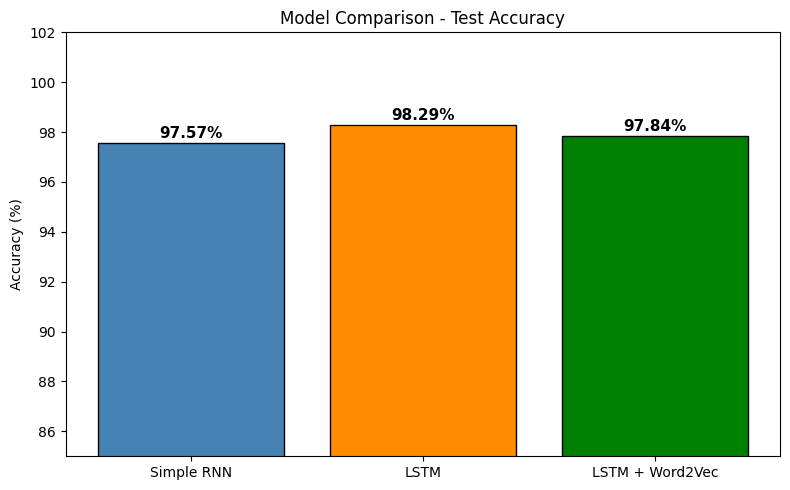

In [43]:
# comparison bar chart
model_names = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']
accuracies  = [acc_rnn*100, acc_lstm*100, acc_w2v*100]

plt.figure(figsize=(8,5))
bars = plt.bar(model_names, accuracies, color=['steelblue','darkorange','green'], edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.title('Model Comparison - Test Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(85, 102)
plt.tight_layout()
plt.show()

## Error Analysis - Wrong Predictions

In [44]:
# looking at what the best model got wrong
X_test_list = X_test.reset_index(drop=True)
y_test_list = y_test.reset_index(drop=True)

wrong = []
for i in range(len(y_test_list)):
    actual = y_test_list[i]
    pred   = y_pred_lstm[i][0]
    if actual != pred:
        wrong.append({
            'message'  : X_test_list[i],
            'actual'   : 'spam' if actual == 1 else 'ham',
            'predicted': 'spam' if pred == 1 else 'ham'
        })

wrong_df = pd.DataFrame(wrong)
print(f'total wrong predictions (LSTM): {len(wrong_df)}')
print()
print('sample wrong predictions:')
print(wrong_df.head(5).to_string(index=False))

total wrong predictions (LSTM): 19

sample wrong predictions:
                                                                               message actual predicted
                                                       freemsgfav xmas tonesreply real   spam       ham
        xclusiveclubsaisai morow soiree speciale zouk nichols parisfree rose lady info   spam       ham
         download many ringtones like restriction choose even send yr buddy txt sir å£   spam       ham
              performance award calculated every two monthnot current one month period    ham      spam
get phone want chat set meet call cum moro love jane xx callså£minmoremobsemspoboxpowa   spam       ham


In [45]:
# what types of errors
print('false positives (ham predicted as spam):')
fp = wrong_df[wrong_df['actual']=='ham']
print(len(fp))

print('\nfalse negatives (spam predicted as ham):')
fn = wrong_df[wrong_df['actual']=='spam']
print(len(fn))

# false negatives are more dangerous - spam slipping through

false positives (ham predicted as spam):
5

false negatives (spam predicted as ham):
14


## Simple Spam Predictor

In [46]:
def predict_spam(message, model=model_lstm):
    cleaned = clean_text(message)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    prob = model.predict(padded, verbose=0)[0][0]
    label = 'SPAM' if prob > 0.5 else 'HAM'
    print(f'Message : {message}')
    print(f'Result  : {label} (confidence: {prob:.2f})')
    print()

# testing with sample messages
predict_spam('Congratulations! You have won a free prize. Call now to claim!')
predict_spam('Hey, are you coming to the meeting tomorrow?')
predict_spam('FREE entry to win 1000 pounds text WIN to 8888 now!!!')
predict_spam('Ok i will be there in 10 minutes')

Message : Congratulations! You have won a free prize. Call now to claim!
Result  : SPAM (confidence: 0.99)

Message : Hey, are you coming to the meeting tomorrow?
Result  : HAM (confidence: 0.00)

Message : FREE entry to win 1000 pounds text WIN to 87121 now!!!
Result  : SPAM (confidence: 0.99)

Message : Ok i will be there in 10 minutes
Result  : HAM (confidence: 0.00)

